In [31]:
import numpy as np
import pandas as pd
import warnings
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler
from dowhy import CausalModel
import graphviz
from IPython.display import display
import importlib, tests
importlib.reload(tests)

warnings.filterwarnings("ignore", category=DataConversionWarning)


In [32]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)

download_order = [
    "<100","100-500","500-1k","1k-5k","5k-10k","10k-50k",
    "50k-100k","100k-500k","500k-1M","1M-5M",">5M"
]
ord_map = {c:i for i,c in enumerate(download_order)}
df["app_popularity_encoded"] = df["app_popularity"].map(ord_map)
df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

print("Rows:", len(df))
print("Popularity counts:\n", df["app_popularity"].value_counts().reindex(download_order, fill_value=0))
print("is_third_party counts:\n", df["is_third_party"].value_counts())


Rows: 5612
Popularity counts:
 app_popularity
<100         626
100-500      604
500-1k       317
1k-5k        323
5k-10k       415
10k-50k      449
50k-100k     413
100k-500k    704
500k-1M      602
1M-5M        641
>5M          518
Name: count, dtype: int64
is_third_party counts:
 is_third_party
1    5101
0     511
Name: count, dtype: int64


In [33]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]

baseline_bucket = "<100"
baseline_code = ord_map[baseline_bucket]

results = []


In [34]:
def balance_bucket_pair_bootstrap(df_sub, bucket_col, baseline_code, treated_code,  random_state=42):
    base = df_sub[df_sub[bucket_col] == baseline_code]
    trt  = df_sub[df_sub[bucket_col] == treated_code]

    n_base = len(base)
    n_trt  = len(trt)

    base_bal = base.copy()

    if n_trt >= n_base:
        trt_bal = trt.sample(n=n_base, replace=False, random_state=random_state)
    else:
        trt_bal = trt.sample(n=n_base, replace=True,  random_state=random_state)

    out = pd.concat([base_bal, trt_bal], axis=0)
    out = out.sample(frac=1, random_state=random_state).reset_index(drop=True)


    return out


In [35]:

# APK size and is_third_party as confounders
def generate_causal_graph():
    causal_graph = """
    digraph {
        combined -> verdict;
        is_third_party -> combined;
        is_third_party -> verdict;
        apk_size_scaled -> combined;
        apk_size_scaled -> verdict;
        is_third_party -> apk_size_scaled;
    }
    """

    return causal_graph


# APK size and is_third_party as confounders
def estimate_causal_effect(df_sub, causal_graph):
    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=causal_graph.replace("\n", " "),
        common_causes=["is_third_party", "apk_size_scaled"]
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_matching",
        target_units="ate",
        confidence_intervals='bootstrap',
        method_params={
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        },
    )
    
    return model,identified_estimand,estimate


    
# # APK size is not a confounder, only is_third_party is a confounder
# def generate_causal_graph():
#     causal_graph = """
#     digraph {
#         combined -> verdict;
#         is_third_party -> combined;
#         is_third_party -> verdict;
#         apk_size_scaled -> combined;
#         is_third_party -> apk_size_scaled;
#     }
#     """

#     return causal_graph


# # APK size is not a confounder, only is_third_party is a confounder
# def estimate_causal_effect(df_sub, causal_graph):
#     model = CausalModel(
#         data=df_sub,
#         treatment="combined",
#         outcome="verdict",
#         graph=causal_graph.replace("\n", " "),
#         common_causes=["is_third_party"]
#     )

#     identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

#     estimate = model.estimate_effect(
#         identified_estimand,
#         method_name="backdoor.propensity_score_matching",
#         target_units="ate",
#         confidence_intervals='bootstrap',
#         method_params={
#             "num_simulations": 300,
#             "sample_size_fraction": 1.0,
#             "confidence_level": 0.95,
#         },
#     )
    
#     return model,identified_estimand,estimate


In [36]:
from dowhy import CausalModel
import dowhy.causal_estimators.linear_regression_estimator as lin

def mediation_graph():
    return """
    digraph {
        combined -> apk_size_scaled;
        combined -> verdict;
        apk_size_scaled -> verdict;
        is_third_party -> apk_size_scaled;
        is_third_party -> combined;
        is_third_party -> verdict;
    }
    """

def estimate_nde_nie(df_sub):
    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=mediation_graph().replace("\n", " "),
        missing_nodes_as_confounders=True
    )

    
    estimand_nde = model.identify_effect(estimand_type="nonparametric-nde",
                                        proceed_when_unidentifiable=True)
    estimand_nie = model.identify_effect(estimand_type="nonparametric-nie",
                                        proceed_when_unidentifiable=True)

    nde = model.estimate_effect(
        estimand_nde,
        method_name="mediation.two_stage_regression",
        method_params={
            "first_stage_model": lin.LinearRegressionEstimator,
            "second_stage_model": lin.LinearRegressionEstimator,
        }
    )
    nie = model.estimate_effect(
        estimand_nie,
        method_name="mediation.two_stage_regression",
        method_params={
            "first_stage_model": lin.LinearRegressionEstimator,
            "second_stage_model": lin.LinearRegressionEstimator,
        }
    )

    # print("NDE:", nde.value)
    # print("NIE:", nie.value)
    return nde, nie


/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur


------------ 100-500 vs <100 ------------
Counts: {1: 1252, 0: 626}
NDE: -0.001526515575743947  || NIE: 0.001526515584290777
combined -> verdict (Spearman)
rho = 0.0076, p = 0.7418


Estimated ATE: -0.026624068157614474
95% CI: (np.float64(-0.13365282215122468), np.float64(0.12513312034078808))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.026624068157614474
New effect:-0.02662406815761448
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.026624068157614474
New effect:0.003245473908413206
p value:0.95


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.026624068157614474
New effect:-0.03918109187749667
p value:0.91



/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur


------------ 500-1k vs <100 ------------
Counts: {1: 1252, 0: 626}
NDE: -0.000875102542543146  || NIE: 0.0008751025335853116
combined -> verdict (Spearman)
rho = -0.0284, p = 0.2187


Estimated ATE: -0.17252396166134185
95% CI: (np.float64(-0.4206602768903088), np.float64(-0.11501597444089456))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.17252396166134185
New effect:-0.1725239616613418
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.17252396166134185
New effect:0.011648029818956336
p value:0.845


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.17252396166134185
New effect:-0.08097203728362183
p value:0.21999999999999997



/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur

...


------------ 500k-1M vs <100 ------------
Counts: {1: 1252, 0: 626}
NDE: -0.02204880480239733  || NIE: 0.022048805678844135
combined -> verdict (Spearman)
rho = 0.0416, p = 0.0715


Estimated ATE: 0.058040468583599576
95% CI: (np.float64(-0.055378061767838126), np.float64(0.29179978700745474))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:0.058040468583599576
New effect:0.058040468583599576
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:0.058040468583599576
New effect:0.004600638977635784
p value:0.9099999999999999


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:0.058040468583599576
New effect:0.006464713715046601
p value:0.69



/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur


------------ 1M-5M vs <100 ------------
Counts: {1: 1252, 0: 626}
NDE: -0.009038530208339954  || NIE: 0.009038532667523256
combined -> verdict (Spearman)
rho = 0.0197, p = 0.3927


Estimated ATE: -0.0878594249201278
95% CI: (np.float64(-0.25559105431309903), np.float64(0.04739084132055374))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.0878594249201278
New effect:-0.08785942492012777
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.0878594249201278
New effect:0.008357294994675187
p value:0.8500000000000001


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.0878594249201278
New effect:-0.060119840213049267
p value:0.81



/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur


------------ >5M vs <100 ------------
Counts: {1: 1252, 0: 626}
NDE: -0.012590075119662356  || NIE: 0.012590062059279414
combined -> verdict (Spearman)
rho = 0.0611, p = 0.0080


Estimated ATE: -0.056975505857294995
95% CI: (np.float64(-0.28541001064962723), np.float64(-0.015441959531416402))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.056975505857294995
New effect:-0.05697550585729498
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.056975505857294995
New effect:-0.0018876464323748666
p value:0.995


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.056975505857294995
New effect:0.033971371504660446
p value:0.21999999999999997



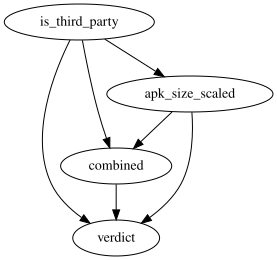

In [37]:
for bucket in download_order:
    if bucket == baseline_bucket:
        continue

    k = ord_map[bucket]

    df_sub = df[df["app_popularity_encoded"].isin([baseline_code, k])].copy()
    df_sub = balance_bucket_pair_bootstrap( df_sub,"app_popularity_encoded", baseline_code, k, random_state=100)

    df_sub["treatment_app_popularity_bucket"] = (df_sub["app_popularity_encoded"] == k).astype(int)
    

    df_all = df_sub.copy()
    df_all["combined"] = 1
    df_baseline = df_sub[df_sub["treatment_app_popularity_bucket"] == 0].copy()
    df_baseline["combined"] = 0
    df_final = pd.concat([df_all, df_baseline], ignore_index=True)
    df_sub = df_final.copy()

    nde, nie = estimate_nde_nie(df_sub)

    
    print("\n" + "-"*12 + f" {bucket} vs {baseline_bucket} " + "-"*12)
    print("Counts:", df_sub["combined"].value_counts().to_dict())
    print("NDE:", nde.value, " || NIE:", nie.value)
    tests.correlation_test_treatment_to_outcome(df_sub)


    causal_graph = generate_causal_graph()

    model, identified_estimand, estimate = estimate_causal_effect(df_sub, causal_graph)

    print("Estimated ATE:", estimate.value)
    try:
        print("95% CI:", estimate.get_confidence_intervals())
    except Exception:
        pass

    results.append({
        "bucket": bucket,
        "ATE_vs_<100": float(estimate.value)
    })

    for method in refutation_methods:
        if method == "placebo_treatment_refuter":
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method,
                placebo_type="permute",
                num_simulations=200
            )
        elif method == "data_subset_refuter":
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method,
                subset_fraction=0.8,
                num_simulations=200
            )
        else:
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method
            )
        print(f"\nRefuter: {method}\n", ref)

g = graphviz.Source(causal_graph)
display(g)

In [38]:
results_df = pd.DataFrame(results)
print("\n\n","-"*25 + "Summary: Bucket-specific ATE vs <100" + "-"*25)
print(results_df)




 -------------------------Summary: Bucket-specific ATE vs <100-------------------------
      bucket  ATE_vs_<100
0    100-500    -0.026624
1     500-1k    -0.172524
2      1k-5k    -0.041534
3     5k-10k    -0.087859
4    10k-50k    -0.035676
5   50k-100k     0.013312
6  100k-500k    -0.104899
7    500k-1M     0.058040
8      1M-5M    -0.087859
9        >5M    -0.056976
